# COSC2793 Computational Machine Learning - Assignment 2

This notebook follows the assessment criteria (A-E) and mirrors the lab workflow.


- A. Task and Dataset Understanding
- B. EDA and Data Handling
- C. Model Development and Performance Analysis
- D. Model Comparison
- E. Final Model Selection and Evaluation

In [4]:
# Core imports and config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# A. Task and Dataset Understanding


Task: We use multi-class classification to predict fire_intensity from wildfire observations features.

In [7]:
# Load data
train_path = './wildfire_cls_train_full.csv'
test_path = './wildfire_cls_test_features.csv'

df = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print('Train shape:', df.shape)
print('Test shape:', df_test.shape)
df.head()
# df_test.head()

Train shape: (4340, 20)
Test shape: (1085, 19)


,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High
3,68.1959,-90.3475,2024-08-26,2240,2024,8.0,Summer,N,North_America,USA,Forest,TERRA,MODIS,389.16,nominal,43.8,17.7,0.98,32.8,Extreme
4,0.6527,118.6227,2025-08-09,2301,2025,8.0,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,MODIS,335.68,high,34.8,1.0,0.18,83.2,Moderate


In [31]:
df.dtypes


latitude          float64
longitude         float64
acq_date           object
acq_time            int64
year                int64
month             float64
season             object
daynight           object
region             object
country            object
fire_type          object
satellite          object
instrument         object
brightness_k      float64
confidence         object
temp_max_c        float64
wind_max_kmh      float64
precip_mm         float64
humidity_pct      float64
fire_intensity     object
dtype: object

We can see that the dataset includes the mixed numeric and categorical features.

Let's see the target type and unique values.

In [17]:
# --- Target normalization: ensure y is integers 0..3 ---
target_col = "fire_intensity"
y_raw = df[target_col]
print("\nRaw target dtype:", y_raw.dtype)
print("Raw target uniques:", sorted(y_raw.dropna().unique().tolist()))


Raw target dtype: object
Raw target uniques: ['Extreme', 'High', 'Low', 'Moderate']


We encode the target fire_intensity to the required 4-class numeric labels (0=Low, 1=Moderate, 2=High, 3=Extreme) so evaluation metrics and the final prediction CSV follow the assignment specification.

In [18]:
label_to_int = {
    "Low": 0,
    "Moderate": 1,
    "High": 2,
    "Extreme": 3,
}

if y_raw.dtype == object:
    y = y_raw.map(label_to_int)
    if y.isna().any():
        bad = sorted(y_raw[y.isna()].unique().tolist())
        raise ValueError(f"Unmapped target labels found: {bad}. Add them to label_to_int.")
else:
    y = y_raw.astype(int)


Get the feature attributes from dataset: 

In [23]:
dataX = df.drop(columns=[target_col])

In [32]:
df.describe()

,latitude,longitude,acq_time,year,month,brightness_k,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,4340.000000,4340.000000,4340.000000,4340.000000,3924.000000,4013.000000,4340.000000,4133.000000,4340.000000,4340.000000
mean,9.821703,29.430626,1177.046774,2024.501843,7.240316,336.677742,35.082627,17.508033,2.597111,37.924378
std,24.321271,78.842700,683.844117,0.500054,2.791615,18.539217,5.821218,17.051980,3.062512,18.731153
min,-42.988300,-167.990600,0.000000,2024.000000,1.000000,290.000000,17.700000,0.000000,0.000000,5.000000
25%,-8.611625,-40.980600,602.000000,2024.000000,5.000000,324.860000,31.000000,5.100000,0.600000,24.200000
50%,10.268500,34.833700,1208.000000,2025.000000,8.000000,335.530000,35.100000,12.400000,1.540000,36.200000
75%,29.011025,95.166775,1752.000000,2025.000000,9.000000,346.990000,39.125000,24.000000,3.370000,50.500000
max,69.930900,153.754900,2359.000000,2025.000000,12.000000,503.710000,54.100000,130.700000,23.690000,95.000000


In [26]:
print("\nMissing values:\n", dataX.isna().sum())


Missing values:
 latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month           416
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k    327
confidence        0
temp_max_c        0
wind_max_kmh    207
precip_mm         0
humidity_pct      0
dtype: int64


The month, brightness_k, wind_max_kmh have missing values.

# B. EDA and Data Handling

Class counts:
 fire_intensity
0     698
1    1921
2    1340
3     381
Name: count, dtype: int64

Class %:
 fire_intensity
0    16.08
1    44.26
2    30.88
3     8.78
Name: count, dtype: float64


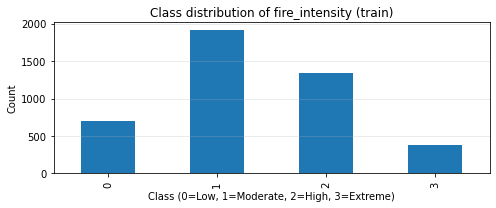

In [28]:
y_ser = pd.Series(y, name="fire_intensity")

counts = y_ser.value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(2)

print("Class counts:\n", counts)
print("\nClass %:\n", pct)

plt.figure(figsize=(7, 3))
counts.plot(kind="bar")
plt.title("Class distribution of fire_intensity (train)")
plt.xlabel("Class (0=Low, 1=Moderate, 2=High, 3=Extreme)")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The target is imbalanced: class 1 dominates while class 3 is the smallest class. Therefore, a model might perform well on the majority class but poorly on the minority class.

The "acq_date" is string, and acq_time is HHMM. We convert them into numberic values which improves the model usability and avoids traeing time as arbitrary interger.

In [40]:
def make_features(df_features: pd.DataFrame) -> pd.DataFrame:
    X = df_features.copy()

    # --- acq_date -> datetime -> numeric features ---

    X["acq_date_dt"] = pd.to_datetime(X["acq_date"], errors="coerce")
    X["acq_month_from_date"] = X["acq_date_dt"].dt.month
    X["acq_dayofyear"] = X["acq_date_dt"].dt.dayofyear
    X["acq_weekday"] = X["acq_date_dt"].dt.weekday

    # Drop the raw string date 
    X = X.drop(columns=["acq_date", "acq_date_dt"])

    # --- acq_time (HHMM) -> hour/minute/minutes_since_midnight ---
    # Ensure numeric first (handles weird formatting safely)
    t = pd.to_numeric(X["acq_time"], errors="coerce")
    X["acq_hour"] = (t // 100).astype("Int64")
    X["acq_minute"] = (t % 100).astype("Int64")

    X["acq_minutes_since_midnight"] = (X["acq_hour"] * 60 + X["acq_minute"]).astype("Int64")

    # Drop original HHMM integer
    X = X.drop(columns=["acq_time"])

    if "month" in X.columns:
        X = X.drop(columns=["month"])

    return X

X_all = make_features(df.drop(columns=[target_col]))
X_submit = make_features(df_test)

We still have the missing values in brightness_k and wind_max_kmh


brightness_k
  missing: 327
  mean   : 336.67774233740346
  median : 335.53
  p05/p95: 309.14599999999996 366.488


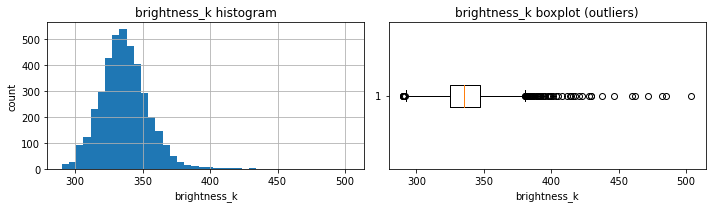


wind_max_kmh
  missing: 207
  mean   : 17.508032905879507
  median : 12.4
  p05/p95: 1.0 52.9


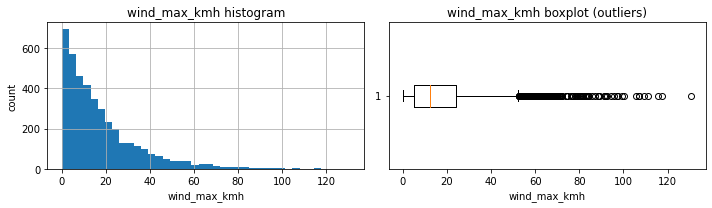

In [39]:
import numpy as np
import matplotlib.pyplot as plt

cols = ["brightness_k", "wind_max_kmh"]

for c in cols:
    s = X0[c]
    print(f"\n{c}")
    print("  missing:", int(s.isna().sum()))
    print("  mean   :", float(s.mean()))
    print("  median :", float(s.median()))
    print("  p05/p95:", float(s.quantile(0.05)), float(s.quantile(0.95)))

    plt.figure(figsize=(10, 3))

    plt.subplot(1, 2, 1)
    s.dropna().hist(bins=40)
    plt.title(f"{c} histogram")
    plt.xlabel(c)
    plt.ylabel("count")

    plt.subplot(1, 2, 2)
    plt.boxplot(s.dropna(), vert=False)
    plt.title(f"{c} boxplot (outliers)")
    plt.xlabel(c)

    plt.tight_layout()
    plt.show()

Use median for the numeric missing values (so: brightness_k and wind_max_kmh):
- wind_max_kmh: the histogram is strongly right‑skewed with a long tail + many outliers in the boxplot → mean will be pulled up, median is robust → median is the better default.
- brightness_k: looks closer to bell-shaped, but your boxplot still shows outliers on the high end. Mean could work, but median is still safe and keeps your preprocessing consistent across numeric features.

## Setup the experiment - data splits


In [43]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=0, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=0, stratify=y_trainval
)

print(X_train.shape[0], X_val.shape[0], X_test.shape[0])

2604 868 868


We impute the data in missing columns, but compute on train only to avoid data leakage. Besides, test is filled using the train median, not the median computed from test.

In [44]:

num_missing_cols = ["brightness_k", "wind_max_kmh"]

# compute fill values on TRAIN only
fill_median = X_train[num_missing_cols].median()

# apply to all sets (including submission features)
X_train[num_missing_cols] = X_train[num_missing_cols].fillna(fill_median)
X_val[num_missing_cols]   = X_val[num_missing_cols].fillna(fill_median)
X_test[num_missing_cols]  = X_test[num_missing_cols].fillna(fill_median)
X_submit[num_missing_cols]= X_submit[num_missing_cols].fillna(fill_median)

print("Train NaNs:", X_train[num_missing_cols].isna().sum().to_dict())
print("Val NaNs  :", X_val[num_missing_cols].isna().sum().to_dict())
print("Test NaNs :", X_test[num_missing_cols].isna().sum().to_dict())

Train NaNs: {'brightness_k': 0, 'wind_max_kmh': 0}
Val NaNs  : {'brightness_k': 0, 'wind_max_kmh': 0}
Test NaNs : {'brightness_k': 0, 'wind_max_kmh': 0}


One-hot encode all sets and align with reindex

In [45]:
# Identify categorical columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols)

# One-hot encode all sets
X_train_oh = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_val_oh   = pd.get_dummies(X_val,   columns=cat_cols, drop_first=False)
X_test_oh  = pd.get_dummies(X_test,  columns=cat_cols, drop_first=False)
X_submit_oh= pd.get_dummies(X_submit,columns=cat_cols, drop_first=False)

# Align val/test/submit to training columns (reindex with fill_value=0)
X_val_oh   = X_val_oh.reindex(columns=X_train_oh.columns, fill_value=0)
X_test_oh  = X_test_oh.reindex(columns=X_train_oh.columns, fill_value=0)
X_submit_oh= X_submit_oh.reindex(columns=X_train_oh.columns, fill_value=0)

print(f"Train shape: {X_train_oh.shape}, Val: {X_val_oh.shape}, Test: {X_test_oh.shape}, Submit: {X_submit_oh.shape}")

Categorical cols: ['season', 'daynight', 'region', 'country', 'fire_type', 'satellite', 'instrument', 'confidence']
Numeric cols: ['latitude', 'longitude', 'year', 'brightness_k', 'temp_max_c', 'wind_max_kmh', 'precip_mm', 'humidity_pct', 'acq_month_from_date', 'acq_dayofyear', 'acq_weekday', 'acq_hour', 'acq_minute', 'acq_minutes_since_midnight']
Train shape: (2604, 81), Val: (868, 81), Test: (868, 81), Submit: (1085, 81)


Model-specific preprocessing

Decision Tree (no scaling needed)


In [46]:
# Convert to numpy for sklearn
X_train_dt = X_train_oh.to_numpy()
X_val_dt   = X_val_oh.to_numpy()
X_test_dt  = X_test_oh.to_numpy()
X_submit_dt= X_submit_oh.to_numpy()

# Ready to train:
# dt_clf = DecisionTreeClassifier(max_depth=..., random_state=0)
# dt_clf.fit(X_train_dt, y_train)
# train_pred = dt_clf.predict(X_train_dt)
# val_pred = dt_clf.predict(X_val_dt)
# test_pred = dt_clf.predict(X_test_dt)
# submit_pred = dt_clf.predict(X_submit_dt)

SVM (fit scaler on train, apply to all)


In [48]:
from sklearn.preprocessing import MinMaxScaler

# Fit scaler ONLY on training data
scaler = MinMaxScaler()
scaler.fit(X_train_oh)

# Transform all sets using training stats
X_train_svm = scaler.transform(X_train_oh)
X_val_svm   = scaler.transform(X_val_oh)
X_test_svm  = scaler.transform(X_test_oh)
X_submit_svm= scaler.transform(X_submit_oh)

# Ready to train:
# svm_clf = SVC(kernel='rbf', C=1.0, random_state=0)
# svm_clf.fit(X_train_svm, y_train)
# train_pred = svm_clf.predict(X_train_svm)
# val_pred = svm_clf.predict(X_val_svm)
# test_pred = svm_clf.predict(X_test_svm)
# submit_pred = svm_clf.predict(X_submit_svm)

Neural Network (same scaling as SVM)

In [49]:
# Use the same scaled data as SVM
# X_train_nn, X_val_nn, X_test_nn, X_submit_nn = X_train_svm, X_val_svm, X_test_svm, X_submit_svm

# Convert to torch tensors
X_train_nn = torch.FloatTensor(X_train_svm)
y_train_nn = torch.LongTensor(y_train.values)

X_val_nn   = torch.FloatTensor(X_val_svm)
y_val_nn   = torch.LongTensor(y_val.values)

X_test_nn  = torch.FloatTensor(X_test_svm)
y_test_nn  = torch.LongTensor(y_test.values)

X_submit_nn= torch.FloatTensor(X_submit_svm)

# Define simple MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

input_dim = X_train_svm.shape[1]
model = MLP(input_dim, hidden_dim=64, output_dim=4)